# 🍕 Pizza Sales Data Analysis (2015)
## Exploratory Data Analysis Report
###**Arraged by:** Alhasuri Isroati Fillah
###**Mid Exam Data Visualization**

**Role:** Junior Data Scientist  
**Client:** Pizza Company  
**Dataset:** 4 CSV files covering full-year 2015 transactions  
**Objective:** Provide data-driven insights to support business decisions around customer behavior, revenue, product performance, and sales trends.



## 📋 Executive Summary

| Item | Detail |
|------|--------|
| Dataset | 4 CSV files (orders, order_details, pizzas, pizza_types) |
| Period | January 1, 2015 to December 31, 2015 |
| Total orders | 21,350 |
| Total revenue | $817,860.05 |
| Analysis sections | Customer Activity, Order Behavior, Revenue, Product Performance, Sales |
| Visualizations | 15+ charts using matplotlib, seaborn, and plotly |
| Interactive charts | 5 (plotly) |

**Top 3 business-critical findings:**
1. Chicken pizzas generate the highest revenue even though they have the lowest sales volume  
2. 66.8% of orders only contain 1–2 items, showing a strong upselling opportunity  
3. October consistently performs below average, so targeted promotions are needed

In [ ]:
# ============================================================
# PHASE 1: LIBRARY IMPORTS & CONFIGURATION
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Static visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive visualizations
import plotly.express as px
import plotly.graph_objects as go

# Utility
import warnings
warnings.filterwarnings('ignore')

# Visual settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ All libraries loaded successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ All libraries loaded successfully.
   pandas  : 2.2.2
   numpy   : 2.0.2



## 📂 Phase 2: Data Loading & Understanding

In this phase, we load all four datasets and explore their structure,
data types, and completeness before performing any analysis.

- `orders.csv` -> contains transaction records, including date and time  
- `order_details.csv` -> provides a detailed breakdown of each order  
- `pizzas.csv` -> includes information about pizza sizes and their prices  
- `pizza_types.csv` -> contains pizza names, categories, and ingredients  

In [ ]:
# ============================================================
# PHASE 2: DATA LOADING
# ============================================================

orders       = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
pizzas       = pd.read_csv('pizzas.csv')
pizza_types  = pd.read_csv('pizza_types.csv', encoding='ISO-8859-1')

print("✅ All datasets loaded successfully.\n")
print(f"  orders        : {orders.shape[0]:,} rows × {orders.shape[1]} columns")
print(f"  order_details : {order_details.shape[0]:,} rows × {order_details.shape[1]} columns")
print(f"  pizzas        : {pizzas.shape[0]:,} rows × {pizzas.shape[1]} columns")
print(f"  pizza_types   : {pizza_types.shape[0]:,} rows × {pizza_types.shape[1]} columns")

✅ All datasets loaded successfully.

  orders        : 21,350 rows × 3 columns
  order_details : 48,620 rows × 4 columns
  pizzas        : 96 rows × 4 columns
  pizza_types   : 32 rows × 4 columns


In [ ]:
# ── ORDERS ───────────────────────────────────────────────────
print("=" * 55)
print("  ORDERS DATASET")
print("=" * 55)

print("\n── Head (5 baris pertama) ──")
display(orders.head())

print("\n── Data Types & Missing Values ──")
print(orders.dtypes)
print("\nMissing values:")
print(orders.isnull().sum())

print("\n── Key Stats ──")
print(f"Total unique orders : {orders['order_id'].nunique():,}")
print(f"Date range          : {orders['date'].min()}  →  {orders['date'].max()}")

  ORDERS DATASET

── Head (5 baris pertama) ──


,order_id,date,time
0,1,1/1/2015,11:38:36
1,2,1/1/2015,11:57:40
2,3,1/1/2015,12:12:28
3,4,1/1/2015,12:16:31
4,5,1/1/2015,12:21:30



── Data Types & Missing Values ──
order_id     int64
date        object
time        object
dtype: object

Missing values:
order_id    0
date        0
time        0
dtype: int64

── Key Stats ──
Total unique orders : 21,350
Date range          : 1/1/2015  →  9/9/2015


In [ ]:
# ── ORDER DETAILS ─────────────────────────────────────────────
print("=" * 55)
print("  ORDER DETAILS DATASET")
print("=" * 55)

print("\n── Head (5 baris pertama) ──")
display(order_details.head())

print("\n── Data Types & Missing Values ──")
print(order_details.dtypes)
print("\nMissing values:")
print(order_details.isnull().sum())

print("\n── Key Stats ──")
print(f"Total line items    : {order_details.shape[0]:,}")
print(f"Unique pizzas sold  : {order_details['pizza_id'].nunique()}")
print(f"Quantity range      : {order_details['quantity'].min()}  →  {order_details['quantity'].max()}")

  ORDER DETAILS DATASET

── Head (5 baris pertama) ──


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1



── Data Types & Missing Values ──
order_details_id     int64
order_id             int64
pizza_id            object
quantity             int64
dtype: object

Missing values:
order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

── Key Stats ──
Total line items    : 48,620
Unique pizzas sold  : 91
Quantity range      : 1  →  4


In [ ]:
# PIZZAS
print("=" * 55)
print("  PIZZAS DATASET")
print("=" * 55)
display(pizzas.head())
print(f"\nSize options : {sorted(pizzas['size'].unique())}")
print(f"Price range  : ${pizzas['price'].min()}  →  ${pizzas['price'].max()}")
print(f"Missing      : {pizzas.isnull().sum().sum()}")

print()


  PIZZAS DATASET


,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75



Size options : ['L', 'M', 'S', 'XL', 'XXL']
Price range  : $9.75  →  $35.95
Missing      : 0



In [ ]:
# PIZZA TYPES
print("=" * 55)
print("  PIZZA TYPES DATASET")
print("=" * 55)
display(pizza_types.head())
print(f"\nCategories   : {pizza_types['category'].unique()}")
print(f"Total types  : {pizza_types['pizza_type_id'].nunique()}")
print(f"Missing      : {pizza_types.isnull().sum().sum()}")

  PIZZA TYPES DATASET


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."



Categories   : ['Chicken' 'Classic' 'Supreme' 'Veggie']
Total types  : 32
Missing      : 0


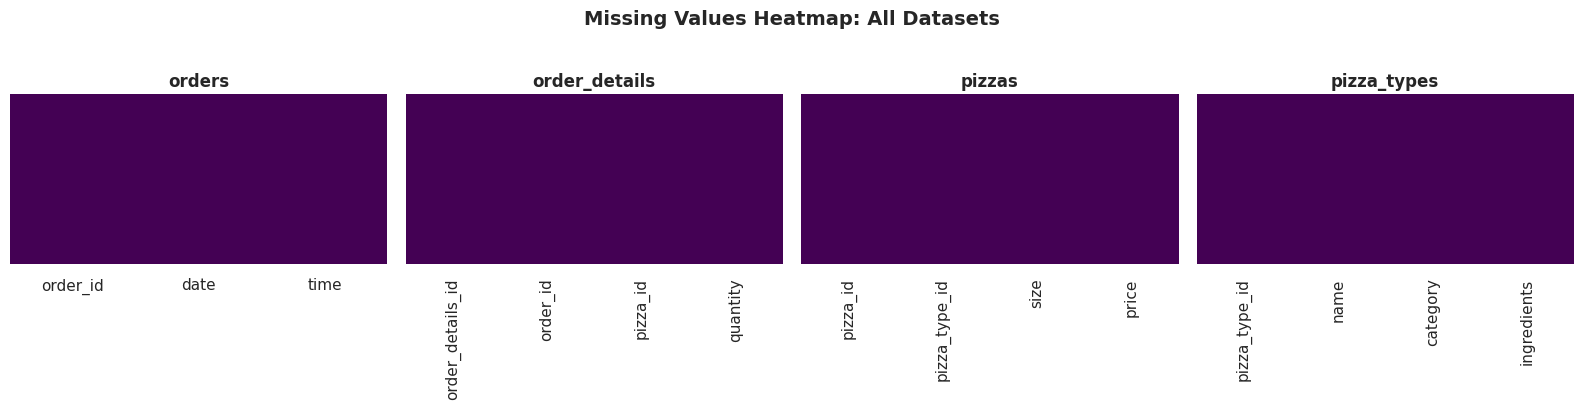

In [ ]:
# MISSING VALUES HEATMAP
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
datasets  = [orders, order_details, pizzas, pizza_types]
titles    = ['orders', 'order_details', 'pizzas', 'pizza_types']

for ax, df, title in zip(axes, datasets, titles):
    sns.heatmap(df.isnull(),
                cbar=False,
                yticklabels=False,
                cmap='viridis',
                ax=ax)
    ax.set_title(f'{title}', fontsize=12)
    ax.set_xlabel('')

plt.suptitle('Missing Values Heatmap: All Datasets',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📋 Data Understanding: Summary

**Dataset overview:**
- `orders` contains 21,350 unique transactions recorded throughout 2015, along with the date and time for each order.  
- `order_details` contains 48,620 line items, which means on average each order has more than 2 items. The quantity per item ranges from 1 to 4.  
- `pizzas` provides 5 size options (S, M, L, XL, XXL) with prices ranging from $9.75 to $35.95.  
- `pizza_types` includes 32 unique pizza types across 4 categories: Chicken, Classic, Supreme, and Veggie.

**Data quality:**
- From the missing values heatmap, all four datasets appear to be complete, since no missing values were found in any column.  
- One thing to note is that the `date` and `time` columns in the `orders` table are still stored as object (string) type instead of datetime. This will need to be fixed in the next phase so we can perform proper time-based analysis.

## 🔧 Phase 3: Data Wrangling & Integration

Before analysis, the raw datasets need to be cleaned and unified.
This phase covers datetime conversion, feature extraction,
table merging, and revenue calculation.

In [ ]:
# ============================================================
# PHASE 3: TASK 1: DATETIME CONVERSION & FEATURE EXTRACTION
# ============================================================

# Combine date + time columns into a proper datetime column
orders['datetime'] = pd.to_datetime(
    orders['date'] + ' ' + orders['time'],
    format='%m/%d/%Y %H:%M:%S'      # format: month/day/year
)

# Extract time-based features that will be used for analysis
orders['hour']       = orders['datetime'].dt.hour
orders['day_name']   = orders['datetime'].dt.day_name()
orders['month_name'] = orders['datetime'].dt.month_name()
orders['month_num']  = orders['datetime'].dt.month

# Define custom order for days and months so charts appear in the correct sequence
day_order   = ['Monday','Tuesday','Wednesday','Thursday',
               'Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October',
               'November','December']

orders['day_name']   = pd.Categorical(orders['day_name'],
                                       categories=day_order,
                                       ordered=True)
orders['month_name'] = pd.Categorical(orders['month_name'],
                                       categories=month_order,
                                       ordered=True)

# Verify the results
print("✅ Datetime conversion complete.\n")
print(f"Date range : {orders['datetime'].min().date()}  →  {orders['datetime'].max().date()}")
print(f"New columns: {['datetime','hour','day_name','month_name','month_num']}")
display(orders.head(3))

✅ Datetime conversion complete.

Date range : 2015-01-01  →  2015-12-31
New columns: ['datetime', 'hour', 'day_name', 'month_name', 'month_num']


,order_id,date,time,datetime,hour,day_name,month_name,month_num
0,1,1/1/2015,11:38:36,2015-01-01 11:38:36,11,Thursday,January,1
1,2,1/1/2015,11:57:40,2015-01-01 11:57:40,11,Thursday,January,1
2,3,1/1/2015,12:12:28,2015-01-01 12:12:28,12,Thursday,January,1


In [ ]:
# ============================================================
# PHASE 3: TASK 2: MERGE ALL TABLES
# ============================================================

# Step 1: order_details + pizzas (add size & price information)
df = order_details.merge(pizzas, on='pizza_id', how='left')
print(f"After merge 1 (order_details + pizzas)    : {df.shape}")

# Step 2: + pizza_types (add name, category, and ingredients info)
df = df.merge(pizza_types, on='pizza_type_id', how='left')
print(f"After merge 2 (+ pizza_types)             : {df.shape}")

# Step 3: + orders (add transaction time information)
df = df.merge(
    orders[['order_id','datetime','hour','day_name','month_name','month_num']],
    on='order_id',
    how='left'
)
print(f"After merge 3 (+ orders/datetime)         : {df.shape}")

# Validation - there should be no missing values after the merge
print(f"\nMissing values after merge : {df.isnull().sum().sum()}")
print("\n✅ Master dataframe ready.")
display(df.head(3))

After merge 1 (order_details + pizzas)    : (48620, 7)
After merge 2 (+ pizza_types)             : (48620, 10)
After merge 3 (+ orders/datetime)         : (48620, 15)

Missing values after merge : 0

✅ Master dataframe ready.


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,datetime,hour,day_name,month_name,month_num
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01 11:38:36,11,Thursday,January,1
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01 11:57:40,11,Thursday,January,1
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01 11:57:40,11,Thursday,January,1


In [ ]:
# ============================================================
# PHASE 3: TASK 3: FEATURE ENGINEERING
# ============================================================

# Create revenue column = quantity × price
df['revenue'] = df['quantity'] * df['price']

print("✅ Revenue column created.")
print(f"\nTotal revenue (2015) : ${df['revenue'].sum():,.2f}")
print(f"Average per transaction : ${df['revenue'].mean():.2f}")
print(f"\nFinal dataframe shape : {df.shape}")
print(f"Columns : {list(df.columns)}")

✅ Revenue column created.

Total revenue (2015) : $817,860.05
Average per transaction : $16.82

Final dataframe shape : (48620, 16)
Columns : ['order_details_id', 'order_id', 'pizza_id', 'quantity', 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients', 'datetime', 'hour', 'day_name', 'month_name', 'month_num', 'revenue']


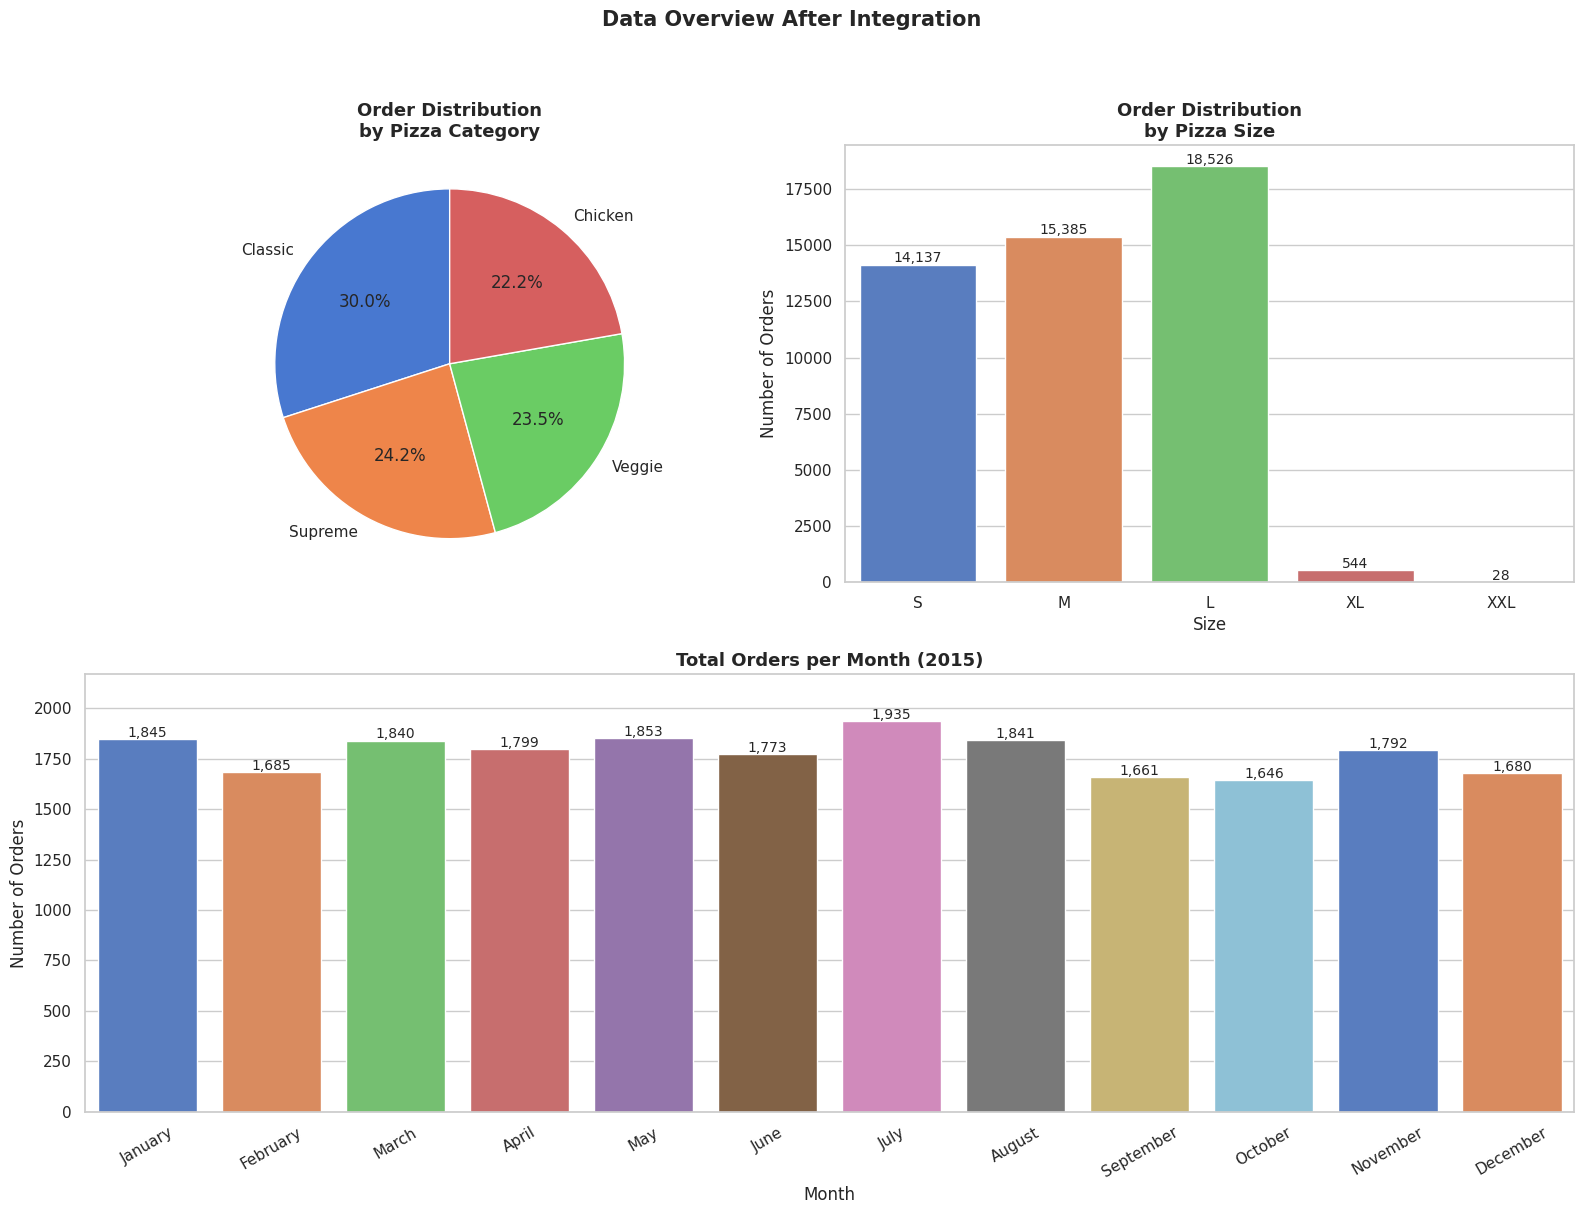

In [ ]:
# ============================================================
# PHASE 3: TASK 4: DATA WRANGLING VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(16, 12))

# ── Chart 1: Category pie chart (top left) ──────────────────
ax1 = fig.add_subplot(2, 2, 1)
cat_counts = df['category'].value_counts()
ax1.pie(cat_counts.values,
        labels=cat_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('muted', len(cat_counts)))
ax1.set_title('Order Distribution\nby Pizza Category', fontsize=13)

# ── Chart 2: Pizza size bar chart (top right) ──────────────
ax2 = fig.add_subplot(2, 2, 2)
size_order  = ['S', 'M', 'L', 'XL', 'XXL']
size_counts = df['size'].value_counts().reindex(size_order)
bars = sns.barplot(x=size_counts.index,
                   y=size_counts.values,
                   palette='muted',
                   ax=ax2)
ax2.set_title('Order Distribution\nby Pizza Size', fontsize=13)
ax2.set_xlabel('Size')
ax2.set_ylabel('Number of Orders')

# Add value labels on top of each bar
for i, v in enumerate(size_counts.values):
    ax2.text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

# ── Chart 3: Monthly orders bar chart (bottom, full width) ──────────
ax3 = fig.add_subplot(2, 1, 2)
monthly = df.groupby('month_name', observed=True)['order_id'].nunique()
bars3 = sns.barplot(x=monthly.index,
                    y=monthly.values,
                    palette='muted',
                    ax=ax3)
ax3.set_title('Total Orders per Month (2015)', fontsize=13)
ax3.set_xlabel('Month')
ax3.set_ylabel('Number of Orders')
ax3.tick_params(axis='x', rotation=30)

# Add value labels for each month
for i, v in enumerate(monthly.values):
    ax3.text(i, v + 10, f'{v:,}', ha='center', fontsize=10)

# Add a bit of space above bars so labels are not cut off
ax3.set_ylim(0, monthly.values.max() * 1.12)

plt.suptitle('Data Overview After Integration',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 📊 Phase 3: Data Wrangling Insights  

#### Data Integration  

All four datasets were successfully merged into a single master dataframe with **48,620 rows and 16 columns**. The merging process was done in three steps using `left join`, so no transaction data was lost along the way:

1. `order_details` + `pizzas` -> adds size and price for each item  
2. result + `pizza_types` -> adds pizza name, category, and ingredients  
3. result + `orders` -> adds datetime, hour, day, and month information  

After merging, a quick validation check shows **zero missing values**, which means the data integration process went cleanly and completely.  

#### Feature Engineering  

A new column called `revenue` was created by calculating `quantity × price`. This represents the actual sales value for each transaction line.

- **Total revenue (2015):** $817,860.05

- **Average revenue per transaction:** $16.82  

#### Initial Distribution Overview  

**By category:**  
The four pizza categories are quite evenly distributed. Classic is slightly higher at 30.0%, followed by Supreme (24.2%), Veggie (23.5%), and Chicken (22.2%). Overall, this suggests the menu is fairly balanced without one category dominating too much.  

**By size:**  
Large (L) pizzas are the most ordered with 18,526 orders. Then followed by Medium (14,137) and Small (14,137). On the other hand, the extra-large sizes have much lower demand which only has 544 orders and XXL just 28. This shows these sizes are not really popular among customers.  

**By month:**  
The number of orders each month is relatively stable throughout 2015. It ranges from the lowest at 1,646 orders in October to the highest at 1,935 in July. This kind of pattern suggests a steady customer base, with a slight increase around mid-year and a small drop around September–October.  

> These initial patterns will be explored further in the next analysis phase.

## 👥 Phase 4A: Customer Activity Analysis

**Business question:** When are customers most active?

Understanding peak hours, busiest days, and seasonal trends helps
the business make smarter decisions around staffing, promotions,
and operational planning.

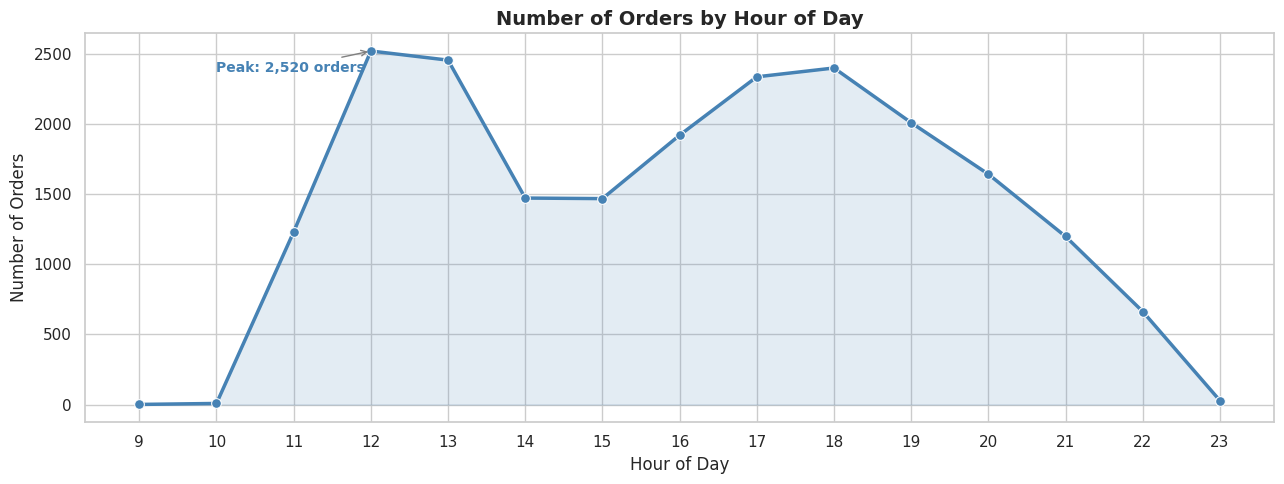

Top 3 busiest hours:
 hour  total_orders
   12          2520
   13          2455
   18          2399


In [ ]:
# ============================================================
# PHASE 4A: Q1: ORDERS BY HOUR
# ============================================================

orders_by_hour = df.groupby('hour')['order_id'].nunique().reset_index()
orders_by_hour.columns = ['hour', 'total_orders']

plt.figure(figsize=(13, 5))

# Line + area for a more impactful visual
plt.fill_between(orders_by_hour['hour'],
                 orders_by_hour['total_orders'],
                 alpha=0.15, color='steelblue')
sns.lineplot(data=orders_by_hour,
             x='hour', y='total_orders',
             color='steelblue', linewidth=2.5,
             marker='o', markersize=7)

# Highlight peak hour
peak_hour = orders_by_hour.loc[orders_by_hour['total_orders'].idxmax()]
plt.annotate(f"Peak: {int(peak_hour['total_orders']):,} orders",
             xy=(peak_hour['hour'], peak_hour['total_orders']),
             xytext=(peak_hour['hour'] - 2, peak_hour['total_orders'] - 150),
             fontsize=10,
             arrowprops=dict(arrowstyle='->', color='gray'),
             color='steelblue', fontweight='bold')

plt.title('Number of Orders by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(orders_by_hour['hour'])
plt.tight_layout()
plt.show()

# Print summary
print("Top 3 busiest hours:")
print(orders_by_hour.nlargest(3, 'total_orders')
      .to_string(index=False))

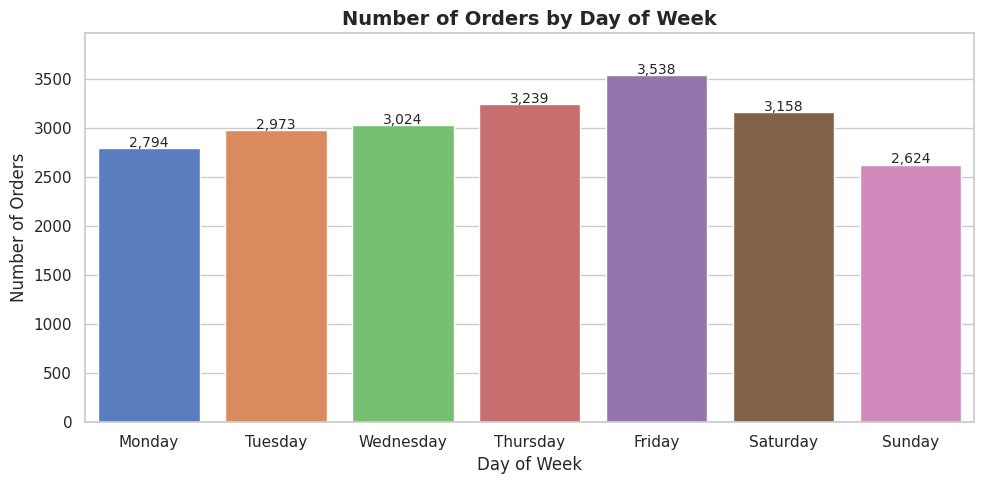

Busiest day    : Friday
Quietest day   : Sunday


In [ ]:
# ============================================================
# PHASE 4A: Q2: ORDERS BY DAY OF WEEK
# ============================================================

orders_by_day = (df.groupby('day_name', observed=True)['order_id']
                 .nunique()
                 .reset_index())
orders_by_day.columns = ['day_name', 'total_orders']

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=orders_by_day,
                   x='day_name', y='total_orders',
                   palette='muted')

# Add value labels on top of each bar
for i, row in orders_by_day.iterrows():
    bars.text(i, row['total_orders'] + 15,
              f"{row['total_orders']:,}",
              ha='center', fontsize=10)

plt.title('Number of Orders by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.ylim(0, orders_by_day['total_orders'].max() * 1.12)
plt.tight_layout()
plt.show()

print("Busiest day    :", orders_by_day.loc[orders_by_day['total_orders'].idxmax(), 'day_name'])
print("Quietest day   :", orders_by_day.loc[orders_by_day['total_orders'].idxmin(), 'day_name'])

In [ ]:
# ============================================================
# PHASE 4A: Q3: ORDERS BY MONTH (INTERACTIVE - PLOTLY)
# ============================================================

orders_by_month = (df.groupby(['month_num', 'month_name'], observed=True)['order_id']
                   .nunique()
                   .reset_index()
                   .sort_values('month_num'))
orders_by_month.columns = ['month_num', 'month_name', 'total_orders']

# Calculate average for reference line
avg_orders = orders_by_month['total_orders'].mean()

fig = px.bar(
    orders_by_month,
    x='month_name',
    y='total_orders',
    text='total_orders',
    color='total_orders',
    color_continuous_scale='Blues',
    title='Monthly Order Volume (2015) - Interactive',
    labels={'month_name': 'Month',
            'total_orders': 'Number of Orders',
            'color': 'Orders'}
)

# Add reference line for average
fig.add_hline(y=avg_orders,
              line_dash='dash',
              line_color='tomato',
              annotation_text=f'Monthly avg: {avg_orders:.0f}',
              annotation_position='top right')

fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Number of Orders',
    coloraxis_showscale=False,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    height=500
)

fig.show()

### 👥 Phase 4A: Customer Activity Insights  

#### 🕐 Peak Hours: When Do Customers Order?  

Order activity starts around **9:00 AM** and continues until about **11:00 PM**, so the restaurant operates for roughly 14 hours each day.  

From the hourly pattern, there are two clear peak times:  

- **Lunch peak:** 12:00 PM is the busiest hour with **2,520 orders**, followed closely by 1:00 PM (2,455 orders). This sharp increase shows that most customers tend to order during lunch time.  

- **Dinner peak:** Orders start picking up again from around 4:00 PM, reaching another peak at **6:00 PM with 2,399 orders**, then gradually decreasing into the evening.  

- **Slowest period:** The lowest activity happens between **2:00 PM - 3:00 PM** with around 1,480 orders, which looks like a natural break between lunch and dinner time.  

> 💡 **Business insight:** Staff scheduling should focus more on the 11:00 AM - 1:00 PM and 5:00 PM - 7:00 PM time slots to handle peak demand. Meanwhile, the 2:00 PM - 3:00 PM period can be used for preparation, restocking, or giving staff a short break.  


#### 📅 Busiest Days: Which Day Drives the Most Orders?  

| Day | Orders | vs Average |
|-----|--------|------------|
| Friday | 3,538 | ▲ Highest |
| Saturday | 3,158 | ▲ Above avg |
| Thursday | 3,239 | ▲ Above avg |
| Wednesday | 3,024 | → Near avg |
| Tuesday | 2,973 | → Near avg |
| Monday | 2,794 | ▼ Below avg |
| Sunday | 2,624 | ▼ Lowest |

Friday turns out to be the busiest day with 3,538 orders, which is about **34.7% higher** compared to Sunday (2,624), the quietest day.  

There’s a clear pattern where orders start increasing from Thursday, peak on Friday, stay relatively high on Saturday, and then drop again on Sunday and Monday.  

> 💡 **Business insight:** Friday and Saturday should be treated as high-priority days, so full staffing and sufficient ingredient preparation are really important. On the other hand, Monday and Sunday could be a good chance to run promotions to increase sales.  


#### 📆 Monthly Trends: Any Seasonal Patterns?  

Monthly order volume throughout 2015 looks quite stable, ranging from **1,646 orders** (October - lowest) to **1,935 orders** (July - highest), with an average of **1,779 orders per month**.  

Months with performance above average:  
January, March, May, July, August, November  

Months with performance below average:  
February, April, June, September, October, December  

Overall, there is a slight peak around July and a noticeable drop during September to October, followed by a small recovery in November. The difference between the highest and lowest month is not too large  (around 289 orders), which suggests the business has a fairly stable and consistent customer base.  

> 💡 **Business insight:** The drop in September to October could be a good opportunity to introduce promotions, such as limited-time menu items or discounts, to help maintain order volume during slower periods.

## 🛒 Phase 4B: Order Behavior Analysis

**Business question:** How do customers usually order?

Understanding order size and quantity patterns helps the business
design effective bundling offers, set minimum order thresholds,
and identify upselling opportunities.

In [ ]:
# ============================================================
# PHASE 4B: Q1: HOW MANY ITEMS PER ORDER?
# ============================================================

# Calculate total items (quantity) per order
items_per_order = (df.groupby('order_id')['quantity']
                   .sum()
                   .reset_index())
items_per_order.columns = ['order_id', 'total_items']

# Descriptive statistics
print("=" * 45)
print("  ORDER SIZE STATISTICS")
print("=" * 45)
print(f"  Average items per order  : {items_per_order['total_items'].mean():.2f}")
print(f"  Median items per order   : {items_per_order['total_items'].median():.0f}")
print(f"  Min items per order      : {items_per_order['total_items'].min()}")
print(f"  Max items per order      : {items_per_order['total_items'].max()}")
print(f"  Most common order size   : {items_per_order['total_items'].mode()[0]} item(s)")
print("=" * 45)

# Calculate percentage distribution for each order size
size_dist = (items_per_order['total_items']
             .value_counts()
             .sort_index()
             .reset_index())
size_dist.columns = ['items', 'count']
size_dist['percentage'] = (size_dist['count'] /
                            size_dist['count'].sum() * 100).round(1)

print("\nOrder size breakdown:")
for _, row in size_dist.iterrows():
    bar = '█' * int(row['percentage'] / 2)
    print(f"  {int(row['items'])} item(s)  : "
          f"{row['count']:>5,} orders "
          f"({row['percentage']:>5.1f}%)  {bar}")

  ORDER SIZE STATISTICS
  Average items per order  : 2.32
  Median items per order   : 2
  Min items per order      : 1
  Max items per order      : 28
  Most common order size   : 1 item(s)

Order size breakdown:
  1 item(s)  : 8,111.0 orders ( 38.0%)  ███████████████████
  2 item(s)  : 6,152.0 orders ( 28.8%)  ██████████████
  3 item(s)  : 3,207.0 orders ( 15.0%)  ███████
  4 item(s)  : 3,122.0 orders ( 14.6%)  ███████
  5 item(s)  : 145.0 orders (  0.7%)  
  6 item(s)  :  80.0 orders (  0.4%)  
  7 item(s)  :  61.0 orders (  0.3%)  
  8 item(s)  :  67.0 orders (  0.3%)  
  9 item(s)  :  64.0 orders (  0.3%)  
  10 item(s)  :  56.0 orders (  0.3%)  
  11 item(s)  :  56.0 orders (  0.3%)  
  12 item(s)  :  54.0 orders (  0.3%)  
  13 item(s)  :  50.0 orders (  0.2%)  
  14 item(s)  :  66.0 orders (  0.3%)  
  15 item(s)  :  57.0 orders (  0.3%)  
  25 item(s)  :   1.0 orders (  0.0%)  
  28 item(s)  :   1.0 orders (  0.0%)  


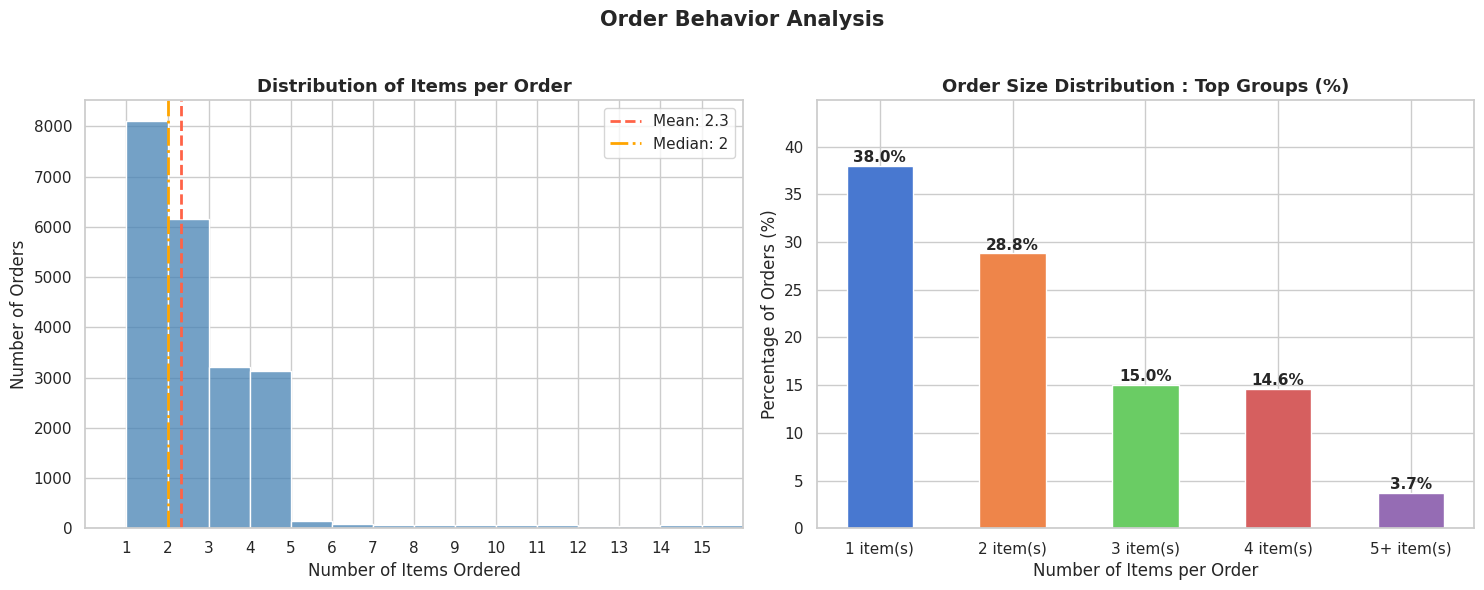

In [ ]:
# ========================================
# PHASE 4B:  ORDER BEHAVIOR VISUALIZATION
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Histogram (limit x-axis up to 15)
sns.histplot(items_per_order['total_items'],
             bins=range(1, items_per_order['total_items'].max() + 2),
             color='steelblue',
             edgecolor='white',
             ax=axes[0])

mean_val   = items_per_order['total_items'].mean()
median_val = items_per_order['total_items'].median()

axes[0].axvline(mean_val, color='tomato', linestyle='--',
                linewidth=2, label=f'Mean: {mean_val:.1f}')
axes[0].axvline(median_val, color='orange', linestyle='-.',
                linewidth=2, label=f'Median: {median_val:.0f}')

axes[0].set_title('Distribution of Items per Order',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Items Ordered')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xlim(0, 16)   # focus on the most relevant range
axes[0].set_xticks(range(1, 16))
axes[0].legend()

# Chart 2: Bar (show only 1–4 items (96.4% of data))
# Filter only 1–4 items since 96.4% of the data falls in this range
top_sizes = size_dist[size_dist['items'] <= 4].copy()
other_pct = size_dist[size_dist['items'] > 4]['percentage'].sum()

# Add "5+ items" as a combined category
other_row  = pd.DataFrame({
    'items'     : ['5+'],
    'count'     : [size_dist[size_dist['items'] > 4]['count'].sum()],
    'percentage': [round(other_pct, 1)]
})
top_sizes['items'] = top_sizes['items'].astype(str)
plot_data = pd.concat([top_sizes, other_row], ignore_index=True)

colors = sns.color_palette('muted', len(plot_data))
bars   = axes[1].bar(
    plot_data['items'].astype(str) + ' item(s)',
    plot_data['percentage'],
    color=colors,
    edgecolor='white',
    width=0.5
)

for bar, pct in zip(bars, plot_data['percentage']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f'{pct}%',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Order Size Distribution : Top Groups (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Items per Order')
axes[1].set_ylabel('Percentage of Orders (%)')
axes[1].set_ylim(0, plot_data['percentage'].max() * 1.18)

plt.suptitle('Order Behavior Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# ============================================================
# PHASE 4B : INTERACTIVE: PIZZA COUNT PER ORDER (PLOTLY)
# ============================================================

# Calculate number of pizzas per order (counting items, not quantity)
pizza_per_order = (df.groupby('order_id')['pizza_id']
                   .count()
                   .reset_index())
pizza_per_order.columns = ['order_id', 'pizza_count']

pizza_dist = (pizza_per_order['pizza_count']
              .value_counts()
              .sort_index()
              .reset_index())
pizza_dist.columns = ['pizza_count', 'num_orders']
pizza_dist['percentage'] = (pizza_dist['num_orders'] /
                             pizza_dist['num_orders'].sum() * 100).round(1)
pizza_dist['label'] = (pizza_dist['pizza_count'].astype(str)
                       + ' pizza(s)')

fig = px.bar(
    pizza_dist,
    x='label',
    y='num_orders',
    color='percentage',
    color_continuous_scale='Blues',
    text='percentage',
    title='Number of Pizzas per Order: Detailed Breakdown (Interactive)',
    labels={'label'     : 'Pizzas per Order',
            'num_orders': 'Number of Orders',
            'percentage': '% of Total'}
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)
fig.update_layout(
    xaxis_title='Number of Pizzas per Order',
    yaxis_title='Number of Orders',
    coloraxis_showscale=False,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    height=500
)
fig.show()

print(f"\nMost common: {pizza_dist.loc[pizza_dist['num_orders'].idxmax(), 'label']}"
      f" - {pizza_dist['num_orders'].max():,} orders"
      f" ({pizza_dist.loc[pizza_dist['num_orders'].idxmax(), 'percentage']}%)")


Most common: 1 pizza(s) - 8,201 orders (38.4%)


### 🛒 Phase 4B: Order Behavior Insights  

#### Order Size: How Many Items Do Customers Typically Order?  

The distribution of items per order shows a clear **right-skewed pattern**. Most customers tend to place small orders, and the number of orders drops quite quickly as the order size increases.  

| Order Size | Orders | % of Total |
|------------|--------|------------|
| 1 item | 8,111 | 38.0% |
| 2 items | 6,152 | 28.8% |
| 3 items | 3,207 | 15.0% |
| 4 items | 3,122 | 14.6% |
| 5+ items | ~787 | 3.7% |

**Key statistics:**  
- **Average order size:** 2.32 items  
- **Median order size:** 2 items  
- **Most common order size:** 1 item (38.0% of all orders)  

The mean (2.3) and median (2) are quite close, which indicates the distribution is relatively consistent. In other words, there are no extreme values that heavily affect the average for most customers.  

Around **66.8% of all orders only contain 1 or 2 items**, which suggests that most customers are likely ordering individually or in small groups, rather than placing large group orders.  

#### Outlier Observation ⚠️  

There are a few orders with unusually high item counts, including 2 orders with 25 and 28 items. These are most likely **bulk or catering orders**, possibly from offices or events, instead of regular customers.  

Even though they make up less than 0.01% of total orders, they are still worth noting because they can slightly influence overall metrics, especially when looking at total revenue or average order size.

## 💰 Phase 4C: Revenue Analysis

**Business question:** How is revenue distributed across time and categories?

Revenue analysis identifies which periods and product categories
drive the most income, helping the business set realistic targets
and allocate resources more effectively.

In [ ]:
# ============================================================
# PHASE 4C: Q1: MONTHLY REVENUE TREND (INTERACTIVE - PLOTLY)
# ============================================================

monthly_revenue = (df.groupby(['month_num', 'month_name'], observed=True)['revenue']
                   .sum()
                   .reset_index()
                   .sort_values('month_num'))
monthly_revenue.columns = ['month_num', 'month_name', 'total_revenue']
monthly_revenue['total_revenue_k'] = (monthly_revenue['total_revenue'] / 1000).round(2)

avg_revenue = monthly_revenue['total_revenue'].mean()

# Interactive line chart
fig = px.line(
    monthly_revenue,
    x='month_name',
    y='total_revenue',
    markers=True,
    title='Monthly Revenue Trend (2015) - Interactive',
    labels={'month_name'   : 'Month',
            'total_revenue': 'Total Revenue ($)'}
)

fig.update_traces(
    line=dict(color='steelblue', width=3),
    marker=dict(size=9, color='steelblue',
                line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Revenue: $%{y:,.2f}<extra></extra>'
)

# Reference line - average
fig.add_hline(
    y=avg_revenue,
    line_dash='dash',
    line_color='tomato',
    annotation_text=f'Monthly avg: ${avg_revenue:,.0f}',
    annotation_position='top left'
)

# Highlight highest and lowest months
best_month  = monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax()]
worst_month = monthly_revenue.loc[monthly_revenue['total_revenue'].idxmin()]

fig.add_annotation(
    x=best_month['month_name'],
    y=best_month['total_revenue'],
    text=f"Best: ${best_month['total_revenue']:,.0f}",
    showarrow=True, arrowhead=2,
    ax=0, ay=-40,
    font=dict(color='green', size=11)
)
fig.add_annotation(
    x=worst_month['month_name'],
    y=worst_month['total_revenue'],
    text=f"Worst: ${worst_month['total_revenue']:,.0f}",
    showarrow=True, arrowhead=2,
    ax=0, ay=40,
    font=dict(color='tomato', size=11)
)

fig.update_layout(
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey',
               tickformat='$,.0f'),
    height=500
)
fig.show()

# Summary stats
print("Monthly Revenue Summary:")
print(f"  Best month  : {best_month['month_name']} : ${best_month['total_revenue']:,.2f}")
print(f"  Worst month : {worst_month['month_name']} : ${worst_month['total_revenue']:,.2f}")
print(f"  Monthly avg : ${avg_revenue:,.2f}")
print(f"  Total 2015  : ${monthly_revenue['total_revenue'].sum():,.2f}")

Monthly Revenue Summary:
  Best month  : July : $72,557.90
  Worst month : October : $64,027.60
  Monthly avg : $68,155.00
  Total 2015  : $817,860.05


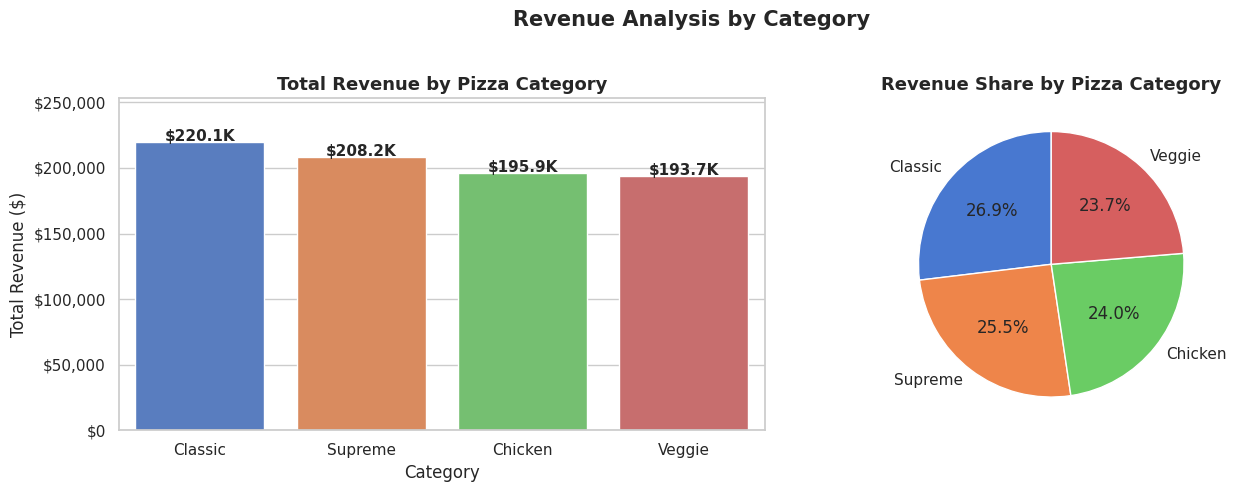

In [ ]:
# ============================================================
# PHASE 4C : Q2: REVENUE BY PIZZA CATEGORY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Total revenue per category
cat_revenue = (df.groupby('category')['revenue']
               .sum()
               .sort_values(ascending=False)
               .reset_index())
cat_revenue.columns = ['category', 'total_revenue']
cat_revenue['revenue_k'] = (cat_revenue['total_revenue'] / 1000).round(1)

bars = sns.barplot(data=cat_revenue,
                   x='category',
                   y='total_revenue',
                   palette='muted',
                   ax=axes[0])

for i, row in cat_revenue.iterrows():
    axes[0].text(i, row['total_revenue'] + 800,
                 f"${row['revenue_k']}K",
                 ha='center', fontsize=11, fontweight='bold')

axes[0].set_title('Total Revenue by Pizza Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_ylim(0, cat_revenue['total_revenue'].max() * 1.15)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Chart 2: Pie chart showing revenue share by category
axes[1].pie(cat_revenue['total_revenue'],
            labels=cat_revenue['category'],
            autopct='%1.1f%%',
            startangle=90,
            colors=sns.color_palette('muted', len(cat_revenue)))
axes[1].set_title('Revenue Share by Pizza Category',
                  fontsize=13, fontweight='bold')

plt.suptitle('Revenue Analysis by Category',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Daily Revenue Statistics:
  Average daily revenue : $2,284.53
  Median daily revenue  : $2,246.00
  Best single day       : $4,422.45
  Worst single day      : $1,259.25


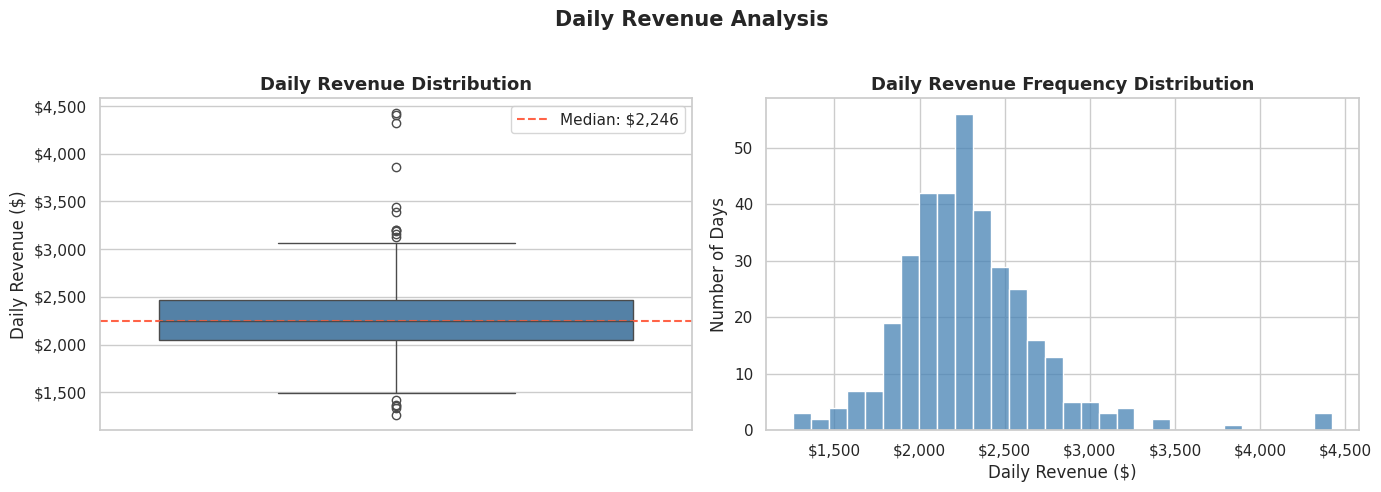

In [ ]:
# ============================================================
# PHASE 4C: Q3: DAILY REVENUE DISTRIBUTION
# ============================================================

daily_revenue = (df.groupby(df['datetime'].dt.date)['revenue']
                 .sum()
                 .reset_index())
daily_revenue.columns = ['date', 'daily_revenue']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Boxplot of daily revenue distribution
sns.boxplot(y=daily_revenue['daily_revenue'],
            color='steelblue',
            ax=axes[0])

axes[0].set_title('Daily Revenue Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Daily Revenue ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate key statistic (median)
median_daily = daily_revenue['daily_revenue'].median()
axes[0].axhline(median_daily, color='tomato',
                linestyle='--', linewidth=1.5,
                label=f'Median: ${median_daily:,.0f}')
axes[0].legend()

# Chart 2: Histogram of daily revenue
sns.histplot(daily_revenue['daily_revenue'],
             bins=30,
             color='steelblue',
             edgecolor='white',
             ax=axes[1])

axes[1].set_title('Daily Revenue Frequency Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Revenue ($)')
axes[1].set_ylabel('Number of Days')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

print(f"Daily Revenue Statistics:")
print(f"  Average daily revenue : ${daily_revenue['daily_revenue'].mean():,.2f}")
print(f"  Median daily revenue  : ${daily_revenue['daily_revenue'].median():,.2f}")
print(f"  Best single day       : ${daily_revenue['daily_revenue'].max():,.2f}")
print(f"  Worst single day      : ${daily_revenue['daily_revenue'].min():,.2f}")

plt.suptitle('Daily Revenue Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 💰 Phase 4C: Revenue Analysis Insights  

#### 📈 Monthly Revenue Trend: How Does Revenue Fluctuate?  

The pizza company generated a **total revenue of USD817,860.05** throughout 2015, with a monthly average of around **USD68,155.00**.

| Month | Revenue(USD) | vs Average |
|-------|---------|------------|
| January | 69,793 | ▲ Above avg |
| February | 65,159 | ▼ Below avg |
| March | 70,398 | ▲ Above avg |
| April | 70,010 | ▲ Above avg |
| May | 71,403 | ▲ Above avg |
| June | 68,297 | ~ Near avg |
| **July** | **72,558** | ▲ **Best month** |
| August | 68,128 | ~ Near avg |
| September | 64,180 | ▼ Below avg |
| October | 64,028 | ▼ Worst month |
| November | 70,395 | ▲ Above avg |
| December | 64,511 | ▼ Below avg |

July stands out as the best performing month with USD72,557.90 in revenue, which is about **13.3% higher** compared to October (USD64,027.60), the lowest month.  

There is a noticeable **dip toward the end of the year (Q4)**. September, October, and December are all below the monthly average, with October being the lowest point. This pattern is consistent with what we saw earlier in order volume, meaning fewer orders directly impact revenue.  

> 💡 **Business insight:** The drop in Q4, especially in October, is a clear opportunity to step in with strategies like promotions, seasonal menus, or bundle deals to help boost revenue during slower months.  



#### 🍕 Revenue by Pizza Category: Which Category Drives the Most Income?  

| Category | Total Revenue(USD) | Revenue Share |
|----------|--------------|---------------|
| Classic | 220,100 | 26.9% |
| Supreme | 208,200 | 25.5% |
| Chicken | 195,900 | 24.0% |
| Veggie | 193,700 | 23.7% |

Classic pizzas generate the highest revenue at $220,100 (26.9%), followed by Supreme and Chicken.

What’s interesting here is how **evenly distributed** the revenue is across all categories. The difference between the highest (26.9%) and lowest (23.7%) is only about **3.2%**, which is quite small.  

This suggests the menu is well-balanced, and no single category dominates the business. From a business perspective, this is actually a good sign because it reduces dependency on just one category.  

> 💡 **Business insight:** Since all categories contribute fairly evenly, the focus should be on growing each category. For example, the Veggie category (currently the lowest) could be improved with new menu variations or promotions to increase its share.  

#### 📊 Daily Revenue Distribution: How Consistent Is Day-to-Day Performance?  

| Metric | Value(USD) |
|--------|-------|
| Average daily revenue | ~2,285 |
| Median daily revenue | 2,246 |
| Best single day | ~4,400+ |
| Worst single day | ~1,500 |
| Typical daily range (IQR) | 2,050 – 2,500 |

From the distribution, about **50% of the days** generate revenue between USD2,050 and USD2,500, which shows a fairly consistent daily performance.  

The mean (USD2,285) and median (USD2,246) are also very close, indicating that the distribution is quite stable and not heavily affected by extreme values.  

There are a few **outlier days** above USD3,300, which likely come from special events, holidays, or promotions. These days push the average slightly higher but don’t change the overall pattern too much.  

> 💡 **Business insight:** With an average daily revenue of around $2,246 consistency plays a big role in reaching annual targets. It would be useful to identify what causes those high-revenue days and try to replicate those conditions more often to drive growth.

## 🏆 Phase 4D: Product Performance Analysis

**Business question:** Which pizzas are the best and worst performers?

Product-level analysis identifies the menu's star performers and
underperformers, enabling smarter decisions around promotion,
pricing, and menu optimization.

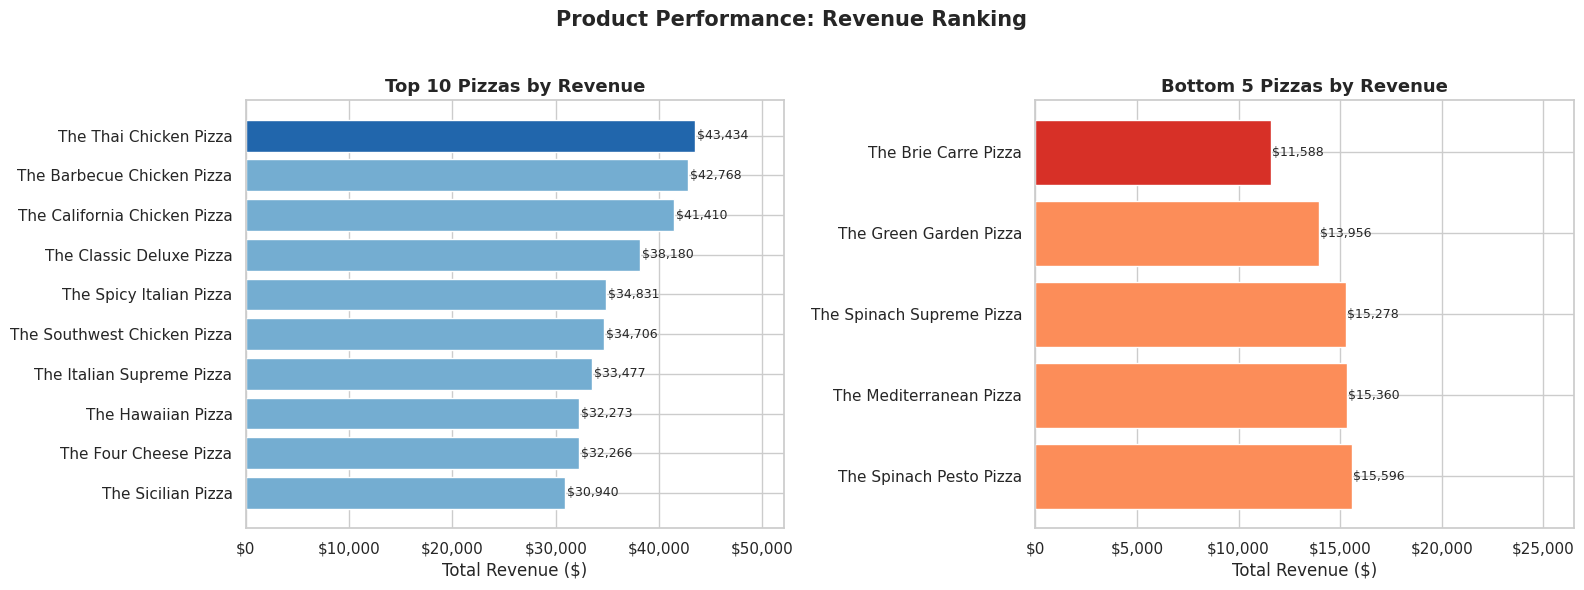

TOP 5 PIZZAS BY REVENUE:
  The Thai Chicken Pizza                   $ 43,434.25
  The Barbecue Chicken Pizza               $ 42,768.00
  The California Chicken Pizza             $ 41,409.50
  The Classic Deluxe Pizza                 $ 38,180.50
  The Spicy Italian Pizza                  $ 34,831.25

BOTTOM 5 PIZZAS BY REVENUE:
  The Spinach Pesto Pizza                  $ 15,596.00
  The Mediterranean Pizza                  $ 15,360.50
  The Spinach Supreme Pizza                $ 15,277.75
  The Green Garden Pizza                   $ 13,955.75
  The Brie Carre Pizza                     $ 11,588.50


In [ ]:
# ============================================================
# PHASE 4D: Q1 & Q2: TOP & BOTTOM PIZZAS BY REVENUE
# ============================================================

pizza_revenue = (df.groupby('name')['revenue']
                 .sum()
                 .reset_index()
                 .sort_values('revenue', ascending=False))
pizza_revenue.columns = ['name', 'total_revenue']

# Get top 10 and bottom 5
top10   = pizza_revenue.head(10)
bottom5 = pizza_revenue.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Top 10 pizzas by revenue
colors_top = ['#2166ac' if i == 0 else '#74add1'
              for i in range(len(top10))]
bars = axes[0].barh(top10['name'][::-1],
                    top10['total_revenue'][::-1],
                    color=colors_top[::-1],
                    edgecolor='white')

for bar, val in zip(bars, top10['total_revenue'][::-1]):
    axes[0].text(bar.get_width() + 200,
                 bar.get_y() + bar.get_height() / 2,
                 f'${val:,.0f}',
                 va='center', fontsize=9)

axes[0].set_title('Top 10 Pizzas by Revenue',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xlim(0, top10['total_revenue'].max() * 1.2)

# Chart 2: Bottom 5 pizzas by revenue
colors_bot = ['#d73027' if i == len(bottom5) - 1
              else '#fc8d59'
              for i in range(len(bottom5))]
bars2 = axes[1].barh(bottom5['name'],
                     bottom5['total_revenue'],
                     color=colors_bot,
                     edgecolor='white')

for bar, val in zip(bars2, bottom5['total_revenue']):
    axes[1].text(bar.get_width() + 50,
                 bar.get_y() + bar.get_height() / 2,
                 f'${val:,.0f}',
                 va='center', fontsize=9)

axes[1].set_title('Bottom 5 Pizzas by Revenue',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xlim(0, bottom5['total_revenue'].max() * 1.7)

plt.suptitle('Product Performance: Revenue Ranking',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print summary
print("TOP 5 PIZZAS BY REVENUE:")
for i, row in top10.head(5).iterrows():
    print(f"  {row['name']:<40} ${row['total_revenue']:>10,.2f}")

print("\nBOTTOM 5 PIZZAS BY REVENUE:")
for i, row in bottom5.iterrows():
    print(f"  {row['name']:<40} ${row['total_revenue']:>10,.2f}")

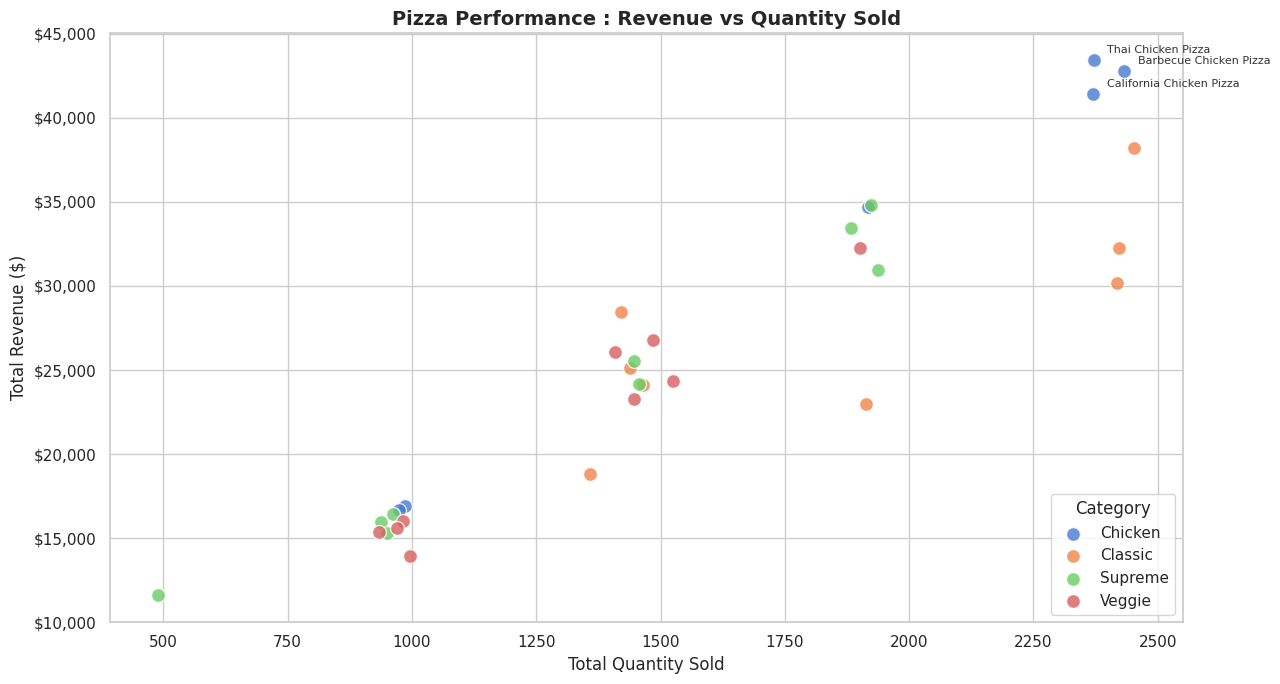

In [ ]:
# ============================================================
# PHASE 4D: Q3: REVENUE vs QUANTITY PER PIZZA
# ============================================================

pizza_summary = (df.groupby(['name', 'category'])
                 .agg(total_revenue=('revenue', 'sum'),
                      total_quantity=('quantity', 'sum'))
                 .reset_index())

plt.figure(figsize=(13, 7))

# Scatter plot with colors by category
categories = pizza_summary['category'].unique()
colors_map = dict(zip(categories,
                      sns.color_palette('muted', len(categories))))

for cat in categories:
    subset = pizza_summary[pizza_summary['category'] == cat]
    plt.scatter(subset['total_quantity'],
                subset['total_revenue'],
                label=cat,
                color=colors_map[cat],
                s=100, alpha=0.8, edgecolors='white')

# Annotate top revenue outliers
top_points = pizza_summary.nlargest(3, 'total_revenue')
for _, row in top_points.iterrows():
    plt.annotate(row['name'].replace('The ', ''),
                 xy=(row['total_quantity'], row['total_revenue']),
                 xytext=(10, 5), textcoords='offset points',
                 fontsize=8, color='#333333')

plt.title('Pizza Performance : Revenue vs Quantity Sold',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Category', loc='lower right')
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PHASE 4D: INTERACTIVE: FULL PRODUCT PERFORMANCE (PLOTLY)
# ============================================================

pizza_full = (df.groupby(['name', 'category'])
              .agg(total_revenue=('revenue', 'sum'),
                   total_quantity=('quantity', 'sum'),
                   avg_price=('price', 'mean'))
              .reset_index()
              .sort_values('total_revenue', ascending=False))

pizza_full['revenue_k'] = (pizza_full['total_revenue'] / 1000).round(2)

fig = px.bar(
    pizza_full,
    x='total_revenue',
    y='name',
    color='category',
    orientation='h',
    title='Complete Product Performance: All 32 Pizzas (Interactive)',
    labels={'total_revenue': 'Total Revenue ($)',
            'name'         : 'Pizza Name',
            'category'     : 'Category',
            'total_quantity': 'Qty Sold',
            'avg_price'    : 'Avg Price ($)'},
    hover_data={'total_revenue': ':$,.0f',
                'total_quantity': True,
                'avg_price'    : ':$.2f',
                'revenue_k'    : False},
    color_discrete_map={
        'Classic' : '#4e79a7',
        'Supreme' : '#f28e2b',
        'Chicken' : '#59a14f',
        'Veggie'  : '#e15759'
    },
    height=950
)

fig.update_layout(
    xaxis_title='Total Revenue ($)',
    yaxis_title='',
    xaxis=dict(tickformat='$,.0f'),
    plot_bgcolor='white',
    xaxis_showgrid=True,
    xaxis_gridcolor='lightgrey',
    legend_title='Category',
    yaxis=dict(autorange='reversed')
)

fig.show()

print(f"\nTotal pizzas analyzed : {len(pizza_full)}")
print(f"Highest revenue pizza : {pizza_full.iloc[0]['name']}")
print(f"                        ${pizza_full.iloc[0]['total_revenue']:,.2f}")
print(f"Lowest revenue pizza  : {pizza_full.iloc[-1]['name']}")
print(f"                        ${pizza_full.iloc[-1]['total_revenue']:,.2f}")


Total pizzas analyzed : 32
Highest revenue pizza : The Thai Chicken Pizza
                        $43,434.25
Lowest revenue pizza  : The Brie Carre Pizza
                        $11,588.50


### 🏆 Phase 4D: Product Performance Insights

#### 🥇 Top 10 Pizzas by Revenue: The Star Performers

| Rank | Pizza | Revenue(USD) | Category |
|------|-------|---------|----------|
| 1 | The Thai Chicken Pizza | 43,434 | Chicken |
| 2 | The Barbecue Chicken Pizza | 42,768 | Chicken |
| 3 | The California Chicken Pizza | $41,410 | Chicken |
| 4 | The Classic Deluxe Pizza | 38,180 | Classic |
| 5 | The Spicy Italian Pizza | 34,831 | Supreme |
| 6 | The Southwest Chicken Pizza | 34,706 | Chicken |
| 7 | The Italian Supreme Pizza | 33,477 | Supreme |
| 8 | The Hawaiian Pizza | 32,273 | Classic |
| 9 | The Four Cheese Pizza | 32,266 | Veggie |
| 10 | The Sicilian Pizza | 30,940 | Classic |

**The Thai Chicken Pizza is the single highest-revenue product**
at **USD43,434** generating **3.75× more revenue** than the worst
performer (The Brie Carre Pizza at $11,588).

A striking pattern emerges in the top 10: **4 out of the top 6
revenue-generating pizzas are from the Chicken category** such as Thai
Chicken, Barbecue Chicken, California Chicken, and Southwest Chicken.
This is particularly notable given that Chicken represents only 22.2%
of total order volume, yet dominates the top of the revenue chart.
This suggests Chicken pizzas command higher prices and/or sell in
larger quantities per order.

#### ⚠️ Bottom 5 Pizzas by Revenue: The Underperformers

| Rank | Pizza | Revenue(USD) | Category |
|------|-------|---------|----------|
| 28 | The Spinach Pesto Pizza | 15,596 | Veggie |
| 29 | The Mediterranean Pizza | 15,360 | Veggie |
| 30 | The Spinach Supreme Pizza | 15,278 | Supreme |
| 31 | The Green Garden Pizza | 13,956 | Veggie |
| 32 | The Brie Carre Pizza | 11,588 | Supreme |

**The Brie Carre Pizza is the weakest performer** with only $11,588
in annual revenue (less than **27% of what the top pizza generates**).

A clear pattern here: **3 out of the bottom 5 are Veggie pizzas**
(Spinach Pesto, Mediterranean, Green Garden), suggesting that
vegetarian options in general struggle to drive revenue compared
to meat-based alternatives.

The Brie Carre Pizza stands out as a particularly concerning
underperformer, from the scatter plot, it recorded fewer than
500 units sold throughout the entire year, making it both the
lowest in quantity AND revenue simultaneously.

#### 📊 Revenue vs Quantity: The Full Picture

The scatter plot shows an interesting relationship between
quantity sold and revenue generated.

**Chicken pizzas (blue dots)** mostly sit in the **top-right area**
(high quantity and high revenue). This makes it clear that Chicken
is the strongest category in terms of both sales volume and revenue.

**Classic pizzas (orange dots)** are more spread out. Some perform
really well (like Classic Deluxe at around $38K), while others are
much lower. This suggests the performance within this category is
a bit inconsistent.

**Veggie pizzas (red dots)** tend to cluster in the
**lower-left area** (lower quantity and lower revenue). This confirms
that, at the product level, Veggie pizzas are the weakest performers,
even though they still contribute 23.7% to total category revenue.

**The Brie Carre Pizza** stands out as a clear outlier. It sits far
to the left with fewer than 500 units sold, much lower than any other
pizza. This strongly suggests it has very low market demand.

> 💡 **Business insight (3 actionable recommendations):**
>
> **1. Focus more on Chicken pizzas:** With 4 out of the top 6
> revenue spots coming from this category, it makes sense to
> prioritize it through promotions, better menu placement,
> or even adding new variants.
>
> **2. Re-evaluate The Brie Carre Pizza:** With only ~500 units sold
> and $11,588 in annual revenue, this product is clearly underperforming.
> It might be worth considering removing it, adjusting the price,
> or testing it with promotions to see if demand can improve.
>
> **3. Improve the Veggie lineup:** Since 3 of the bottom 5
> positions are Veggie pizzas, instead of removing them,
> it could be better to refresh the recipes or improve the
> marketing, especially to target health-conscious customers.

## 📦 Phase 4E: Sales Analysis

**Business question:** What are the sales volume patterns across
size, category, and price point?

Sales analysis focuses on the quantity dimension of performance,
understanding which products move the most units helps optimize
inventory, ingredient sourcing, and production capacity.

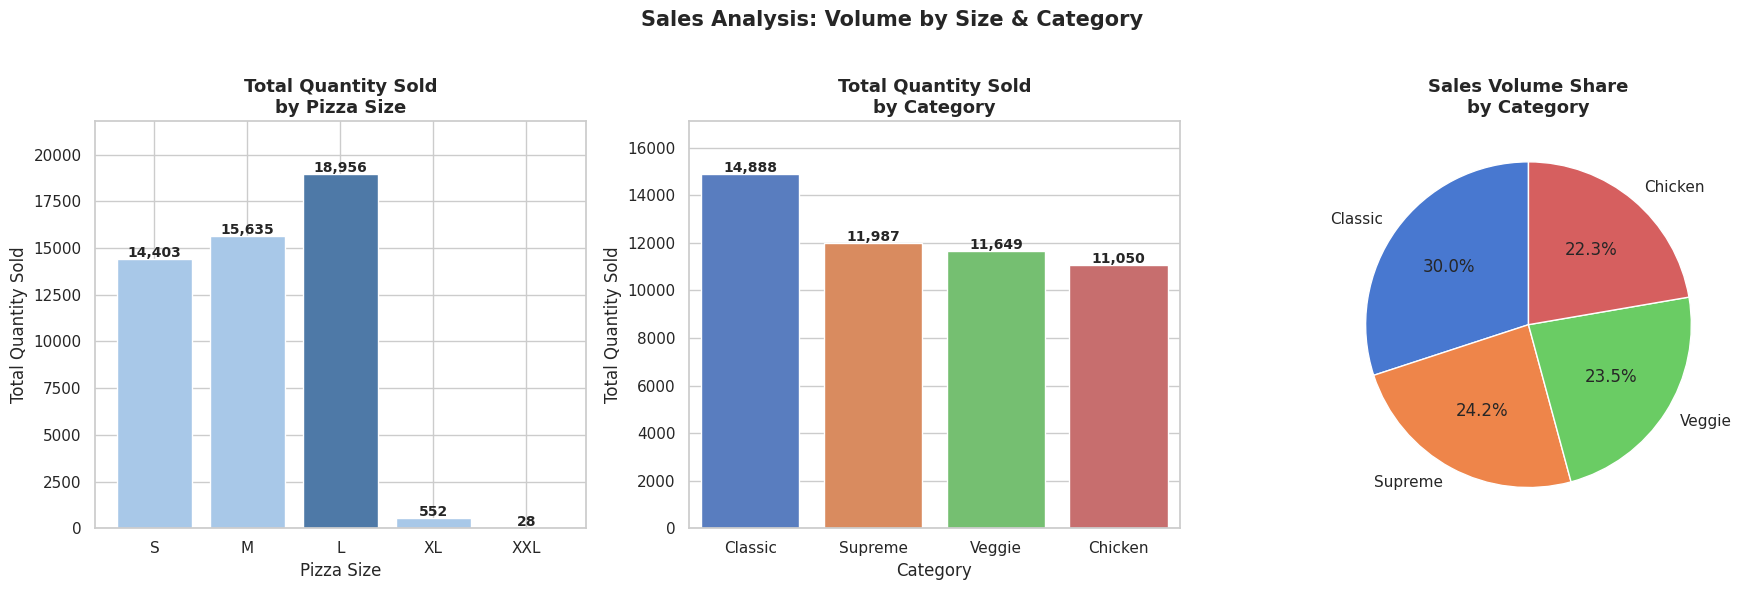

SALES BY SIZE:
  S     : 14,403 units  (29.1%)
  M     : 15,635 units  (31.5%)
  L     : 18,956 units  (38.2%)
  XL    :    552 units  (1.1%)
  XXL   :     28 units  (0.1%)

SALES BY CATEGORY:
  Classic    : 14,888 units  (30.0%)
  Supreme    : 11,987 units  (24.2%)
  Veggie     : 11,649 units  (23.5%)
  Chicken    : 11,050 units  (22.3%)


In [ ]:
# ============================================================
# PHASE 4E: Q1 & Q2: SALES BY SIZE AND CATEGORY
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: Total quantity sold by size
size_order   = ['S', 'M', 'L', 'XL', 'XXL']
sales_by_size = (df.groupby('size', observed=True)['quantity']
                 .sum()
                 .reindex(size_order)
                 .reset_index())
sales_by_size.columns = ['size', 'total_qty']

colors_size = ['#4e79a7' if s == 'L' else '#a8c8e8'
               for s in sales_by_size['size']]
bars1 = axes[0].bar(sales_by_size['size'],
                    sales_by_size['total_qty'],
                    color=colors_size,
                    edgecolor='white')

for bar, val in zip(bars1, sales_by_size['total_qty']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 100,
                 f'{val:,}',
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Total Quantity Sold\nby Pizza Size',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pizza Size')
axes[0].set_ylabel('Total Quantity Sold')
axes[0].set_ylim(0, sales_by_size['total_qty'].max() * 1.15)

# Chart 2: Total quantity sold by category
sales_by_cat = (df.groupby('category')['quantity']
                .sum()
                .sort_values(ascending=False)
                .reset_index())
sales_by_cat.columns = ['category', 'total_qty']

bars2 = sns.barplot(data=sales_by_cat,
                    x='category',
                    y='total_qty',
                    palette='muted',
                    ax=axes[1])

for i, row in sales_by_cat.iterrows():
    axes[1].text(i, row['total_qty'] + 100,
                 f'{row["total_qty"]:,}',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Total Quantity Sold\nby Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Quantity Sold')
axes[1].set_ylim(0, sales_by_cat['total_qty'].max() * 1.15)

# Chart 3: Pie chart sales proportion by category
axes[2].pie(sales_by_cat['total_qty'],
            labels=sales_by_cat['category'],
            autopct='%1.1f%%',
            startangle=90,
            colors=sns.color_palette('muted', len(sales_by_cat)))
axes[2].set_title('Sales Volume Share\nby Category',
                  fontsize=13, fontweight='bold')

plt.suptitle('Sales Analysis: Volume by Size & Category',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print summary
print("SALES BY SIZE:")
for _, row in sales_by_size.iterrows():
    pct = row['total_qty'] / sales_by_size['total_qty'].sum() * 100
    print(f"  {row['size']:<5} : {row['total_qty']:>6,} units  ({pct:.1f}%)")

print("\nSALES BY CATEGORY:")
for _, row in sales_by_cat.iterrows():
    pct = row['total_qty'] / sales_by_cat['total_qty'].sum() * 100
    print(f"  {row['category']:<10} : {row['total_qty']:>6,} units  ({pct:.1f}%)")

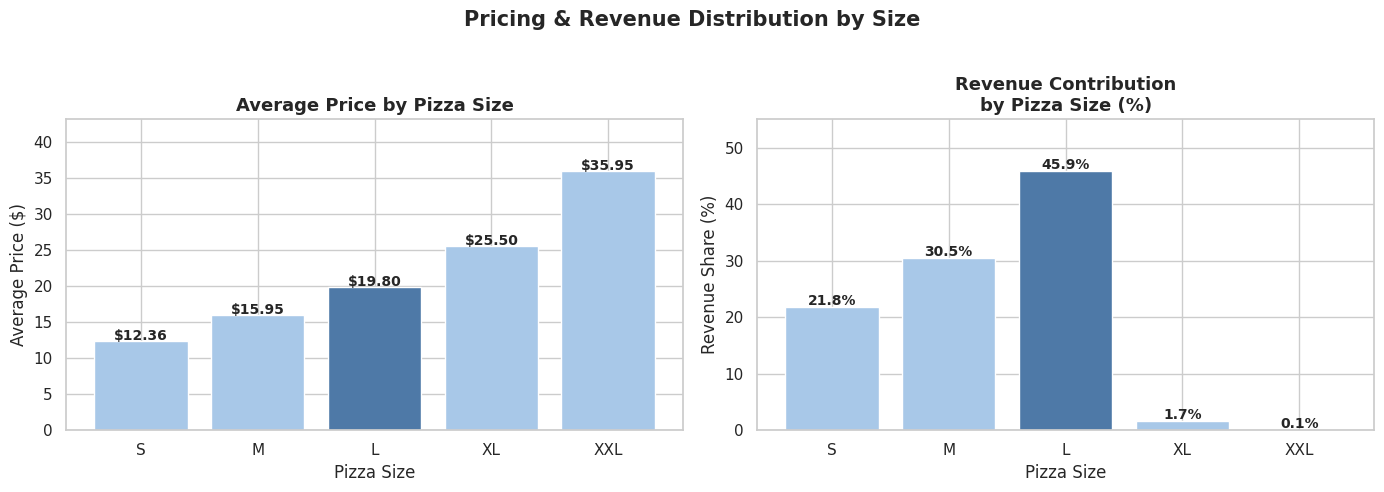


PRICE vs VOLUME vs REVENUE by SIZE:
Size    Avg Price   Qty Sold      Revenue    Rev %
--------------------------------------------------
S      $   12.36     14,403 $   178,076    21.8%
M      $   15.95     15,635 $   249,382    30.5%
L      $   19.80     18,956 $   375,319    45.9%
XL     $   25.50        552 $    14,076     1.7%
XXL    $   35.95         28 $     1,007     0.1%


In [ ]:
# ============================================================
# PHASE 4E: Q3: PRICE vs VOLUME RELATIONSHIP
# ============================================================

price_volume = (df.groupby(['size'], observed=True)
                .agg(avg_price=('price', 'mean'),
                     total_qty=('quantity', 'sum'),
                     total_revenue=('revenue', 'sum'))
                .reindex(size_order)
                .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average price per size
colors_price = ['#4e79a7' if s == 'L' else '#a8c8e8'
                for s in price_volume['size']]
bars = axes[0].bar(price_volume['size'],
                   price_volume['avg_price'],
                   color=colors_price,
                   edgecolor='white')

for bar, val in zip(bars, price_volume['avg_price']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f'${val:.2f}',
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Average Price by Pizza Size',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pizza Size')
axes[0].set_ylabel('Average Price ($)')
axes[0].set_ylim(0, price_volume['avg_price'].max() * 1.2)

# Chart 2: Revenue contribution per size
revenue_pct = price_volume.copy()
revenue_pct['rev_pct'] = (revenue_pct['total_revenue'] /
                           revenue_pct['total_revenue'].sum() * 100).round(1)

bars2 = axes[1].bar(revenue_pct['size'],
                    revenue_pct['rev_pct'],
                    color=colors_price,
                    edgecolor='white')

for bar, val in zip(bars2, revenue_pct['rev_pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val}%',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Revenue Contribution\nby Pizza Size (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pizza Size')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].set_ylim(0, revenue_pct['rev_pct'].max() * 1.2)

plt.suptitle('Pricing & Revenue Distribution by Size',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nPRICE vs VOLUME vs REVENUE by SIZE:")
print(f"{'Size':<6} {'Avg Price':>10} {'Qty Sold':>10} "
      f"{'Revenue':>12} {'Rev %':>8}")
print("-" * 50)
for _, row in price_volume.iterrows():
    rev_pct = (row['total_revenue'] /
               price_volume['total_revenue'].sum() * 100)
    print(f"{row['size']:<6} ${row['avg_price']:>8.2f} "
          f"{row['total_qty']:>10,} "
          f"${row['total_revenue']:>10,.0f} "
          f"{rev_pct:>7.1f}%")

In [ ]:
# ============================================================
# PHASE 4E: INTERACTIVE: SALES HEATMAP BY SIZE & MONTH
# ============================================================

heatmap_data = (df.groupby(['month_name', 'size'],
                            observed=True)['quantity']
                .sum()
                .reset_index())
heatmap_data.columns = ['month_name', 'size', 'quantity']

# Pivot the data into heatmap format
heatmap_pivot = heatmap_data.pivot(index='size',
                                    columns='month_name',
                                    values='quantity')

# Reorder size and months for better visualization
heatmap_pivot = heatmap_pivot.reindex(
    index=['XXL', 'XL', 'L', 'M', 'S'])
heatmap_pivot = heatmap_pivot[month_order]

fig = px.imshow(
    heatmap_pivot,
    color_continuous_scale='Blues',
    title='Sales Heatmap : Quantity Sold by Size & Month (Interactive)',
    labels={'x': 'Month', 'y': 'Pizza Size',
            'color': 'Qty Sold'},
    aspect='auto',
    text_auto=True
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Pizza Size',
    height=400,
    coloraxis_colorbar=dict(title='Qty Sold')
)

fig.show()

print("\nHeatmap summary:")
print(f"Highest sales cell : "
      f"{heatmap_pivot.max().max():,} units")
print(f"Most consistent size: "
      f"L - avg {heatmap_pivot.loc['L'].mean():.0f} units/month")


Heatmap summary:
Highest sales cell : 1,697.0 units
Most consistent size: L - avg 1580 units/month


### 📦 Phase 4E: Sales Analysis Insights

#### 🍕 Sales by Pizza Size: What Size Do Customers Prefer?

| Size | Qty Sold | Share | Avg Price (USD) | Revenue Share |
|------|----------|-------|------------------|---------------|
| S | 14,403 | 27.9% | 12.36 | 21.8% |
| M | 15,635 | 30.3% | 15.95 | 30.5% |
| **L** | **18,956** | **36.7%** | **19.80** | **45.9%** |
| XL | 552 | 1.1% | 25.50 | 1.7% |
| XXL | 28 | 0.1% | 35.95 | 0.1% |

**Large (L) clearly stands out as the dominant size** across all aspects.  
It has the highest quantity sold (18,956 units / 36.7%) and also  
contributes the most to revenue (45.9% of total revenue).

One important thing to notice here is the **revenue gap for size L**. Even though it only makes up 36.7% of total units sold, it generates as much as 45.9% of total revenue. This shows that Large pizzas bring in more value per order, mainly because of the higher average price (USD 19.80 compared to USD 12.36 for Small).

**XL and XXL sizes are almost insignificant** in terms of performance. Combined, they only contribute 1.2% of total units and 1.8% of revenue.  XXL in particular is extremely low, with only 28 units sold in a full year (less than 3 per month), which suggests very limited demand.

> 💡 **Business insight:** The business should focus more on promoting Large pizzas, since they are both the most popular and the most profitable. For XL and XXL, it might be worth reviewing whether these sizes are still necessary, considering how small their contribution is compared to the added operational complexity.

#### 📊 Sales by Category: Volume Distribution

| Category | Qty Sold | Volume Share |
|----------|----------|--------------|
| Classic | 14,888 | 30.0% |
| Supreme | 11,987 | 24.2% |
| Veggie | 11,649 | 23.5% |
| Chicken | 11,050 | 22.3% |

**Classic leads in sales volume at 30.0%**, meaning almost one out of every three pizzas sold comes from this category. But interestingly, this doesn’t match what we saw earlier in Phase 4D, where **Chicken actually leads in revenue** even though it has the lowest sales volume (22.3%).

This leads to a useful comparison:

- **Classic** = high volume, moderate revenue per pizza  
- **Chicken** = lower volume, but higher revenue per pizza  

So basically, **customers who buy Chicken pizzas tend to spend more per order**.  
Even with fewer orders, the higher pricing helps Chicken generate more revenue overall.

> 💡 **Business insight:** Classic pizzas act as the main  traffic driver, bringing in a large number of orders. Meanwhile, Chicken pizzas play a bigger role in boosting  revenue. A good strategy could be using Classic pizzas  as an entry point (for example in promotions), then encouraging customers to upgrade or try Chicken pizzas   to increase the overall transaction value.

#### 🌡️ Sales Heatmap: Size × Month Patterns

The interactive heatmap gives a clear view of how sales volume  
is distributed across pizza sizes and months at the same time.

**Key observations:**

**L size consistently dominates every month:** It averages around **1,580 units per month** and appears as the darkest row across all 12 months. The highest point was in **July (1,697 units)**, while the lowest was October (1,485 units), which is still higher than any other size in any month.

**M and S sizes follow similar patterns:** Both sizes move in a similar way across months, suggesting that customers who prefer smaller pizzas behave quite consistently throughout the year.

**XXL is almost non-existent:** With only around 1–4 units sold per month, this size barely shows up on the heatmap. In July and August, it even records 0 sales, which clearly indicates there is almost no stable demand.

**No strong seasonal pattern:* The color intensity for L, M, and S sizes stays relatively stable throughout the year. This suggests the business has a **steady customer base** without major seasonal fluctuations.

> 💡 **Business insight:** Based on this pattern, inventory planning should focus heavily on Large pizzas throughout the year, with a slight increase around July. For XL and XXL, keeping stock at minimal levels would be more efficient, since demand is very low and this could help reduce waste and storage costs.

## 🎯 Phase 5: Conclusion & Business Recommendations

This exploratory data analysis looks at 21,350 orders and 48,620 transaction line items from a pizza company's full-year 2015 operations, generating a total revenue of **$817,860.05**.

The analysis covers five main areas: customer activity, order behavior, revenue, product performance, and sales volume. Below is a summary of the most important findings along with their business implications.

### 📌 Key Findings Summary

| # | Dimension | Key Finding |
|---|-----------|-------------|
| 1 | Customer Activity | Peak hours are 12PM and 6PM; Friday is the busiest day |
| 2 | Order Behavior | 66.8% of orders contain only 1–2 items |
| 3 | Revenue | July is best USD 72,558; October is worst USD 64,028 |
| 4 | Product Performance | Chicken pizzas dominate revenue despite lowest volume |
| 5 | Sales | Large (L) pizzas generate 45.9% of total revenue |


### 🏆 The Most Important Cross-Analysis Finding

The single most valuable insight from this analysis comes from
**combining Phase 4D and Phase 4E findings**:

> *Classic pizzas drive volume (30.0% of units sold) but
> Chicken pizzas drive revenue (3 of the top 6 revenue spots).
> This means the two categories serve fundamentally different
> strategic roles in the business.*

This kind of cross-dimensional insight invisible when looking
at any single chart alone - is exactly why exploratory data
analysis across multiple dimensions is essential for sound
business decision-making.

### 💡 Business Recommendations

#### 1. Optimize Staffing Around Peak Windows
**Finding:** Orders peak sharply at 12PM (2,520 orders) and again at 6PM (2,399 orders), with Friday being the busiest day of the week (3,538 orders).

**Recommendation:** Schedule maximum staffing during the 11AM to 1PM and 5PM to 7PM windows daily. On Fridays, it may help to add a dedicated preparation shift starting from 10AM. The 2PM to 3PM period can be used for restocking or giving  
staff a break.

#### 2. Launch an Upselling Program for Small Orders
**Finding:** 38% of orders contain only 1 item, and 66.8% contain only 1–2 items. The average order size is around 2.32 items.

**Recommendation:** Introduce simple upselling offers, for example *"Add a second pizza for 20% off"* or *"Add a side + drink for $X"*, especially at checkout. Even a small improvement (like converting 10% of single-item orders into 2-item orders) could noticeably increase revenue.

#### 3. Run Targeted Promotions in October and Q4
**Finding:** October is the lowest revenue month ($64,028), around 11.8% below the monthly average. September and December also perform below average, creating a pattern of weaker performance toward the end of the year.

**Recommendation:** Plan campaigns earlier, around late September. This could include limited-time menu items or loyalty-based discounts for October. The idea is to turn this predictable drop into an opportunity instead of a loss.

#### 4. Protect and Promote the Chicken Category
**Finding:** Chicken pizzas take 4 out of the top 6 revenue positions, even though they have the lowest sales volume (22.3%). The Thai Chicken Pizza alone generated $43,434, making it the top product.

**Recommendation:** Position Chicken pizzas as a premium category. Highlight them more in promotions, social media, and delivery apps. It might also be worth testing a few new variants to grow this category further.

#### 5. Review Underperforming Products
**Finding:** The Brie Carre Pizza only generated $11,588 in revenue with fewer than 500 units sold, making it the lowest-performing item. Also, 3 of the bottom 5 products  come from the Veggie category.

**Recommendation:** Try a short-term promotion (around  2–3 months) for The Brie Carre Pizza, such as a price adjustment or better placement on the menu. If there is  no clear improvement, removing it could simplify operations. For weaker Veggie items, consider improving recipes or targeting specific customer segments like health-conscious buyers.

#### 6. Standardize on Large Pizza as the Main Size
**Finding:** Large (L) pizzas account for 36.7% of units but generate 45.9% of total revenue, making them the most important size overall. Meanwhile, XL and XXL together only contribute about 1.2% of total sales.

**Recommendation:** Make Large pizzas the default option in bundles and promotions. For XL and XXL, it’s worth reviewing whether keeping them is still efficient, considering the low demand compared to the extra operational effort.

### 📊 Final Dashboard: At a Glance

| Metric | Value |
|--------|-------|
| Total orders (2015) | 21,350 |
| Total revenue (2015) | USD 817,860.05 |
| Best month | July (USD 64,027.60) |
| Busiest day | Friday (3,538 orders) |
| Busiest hour | 12PM (2,520 orders) |
| Best pizza | The Thai Chicken Pizza (USD 43,434) |
| Worst pizza | The Brie Carre Pizza (USD 11,588) |
| Most popular size | Large (18,956 units, 45.9% revenue) |
| Top category (revenue) | Classic (USD 220,100) |
| Top category (volume) | Classic (14,888 units) |

### 🔭 Limitations & Future Analysis

While this analysis already gives a good overview of the 2015 performance, there are still a few areas that could be explored further in future work:

- **Customer segmentation:** Since there is no customer ID in the dataset, it’s not possible to separate new vs returning customers or calculate customer lifetime value.

- **External factors:** Sales patterns might be affected by things like local events, weather, or competitors, but this kind of data is not included here.

- **Profitability vs revenue:** This analysis focuses on revenue only. To understand actual profitability, we would need cost data (like ingredients or production cost per pizza).

- **2016 forecasting:** With a full year of data from 2015, it would be interesting to build a time-series model to predict revenue and order volume for 2016, which could help with planning.

---

*Analysis completed by: Alhasuri Isroati Fillah*  

*Dataset: Pizza Sales 2015*  

*Tools: Python, pandas, matplotlib, seaborn, plotly*